<a href="https://colab.research.google.com/github/agustinasriastuti-ds/analisis-kepuasan-dosen/blob/main/Lecturer_Satisfaction_Analysis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#  Import semua library penting
from google.colab import files
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving tb_20232 REV.01.xlsx to tb_20232 REV.01 (1).xlsx


In [4]:
df = pd.read_excel('tb_20232 REV.01.xlsx', sheet_name='tb_20232')

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [5]:
df.head()

,idyes,NPM,kodemk,kelastrnlm,kdpsttrnlm,NIDN,Namadosen,dosen,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10
0,250,22321025,TM402,1,21201,1521,MUHYIDIN,MUHYIDIN,5,5,5,5,5,5,5,5,5,5
1,252,22321007,TM402,1,21201,1521,MUHYIDIN,MUHYIDIN,5,5,5,5,5,5,5,5,5,5
2,3229,22321009,TM402,1,21201,1521,MUHYIDIN,MUHYIDIN,5,5,4,5,5,4,5,4,4,4
3,3239,22321020,TM402,1,21201,1521,MUHYIDIN,MUHYIDIN,5,4,5,4,4,5,4,5,4,5
4,3789,22321003,TM402,1,21201,1521,MUHYIDIN,MUHYIDIN,5,5,5,5,5,5,5,5,5,5


In [6]:
df.shape[1]

18

In [7]:
df.shape[0]

14334

In [8]:
# Baca data dari sheet
df = pd.read_excel('tb_20232 REV.01.xlsx', sheet_name='tb_20232')

# Simpan kolom penting
df['NIM'] = df['NPM']
df['Dosen'] = df['Namadosen']

# Ambil kolom pertanyaan
X = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']]

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [9]:
# Ambil hanya kolom p1 - p10
X = df[['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10']]

# Normalisasi data (penting agar setiap fitur seimbang)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA - Reduksi dimensi ke 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# t-SNE - Visualisasi non-linear dengan parameter lengkap
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init='pca'  # bisa ditambahkan untuk inisialisasi lebih stabil
)
X_tsne = tsne.fit_transform(X_scaled)
df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


/tmp/ipykernel_863/4053983314.py:21: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_863/4053983314.py:21: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_863/4053983314.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


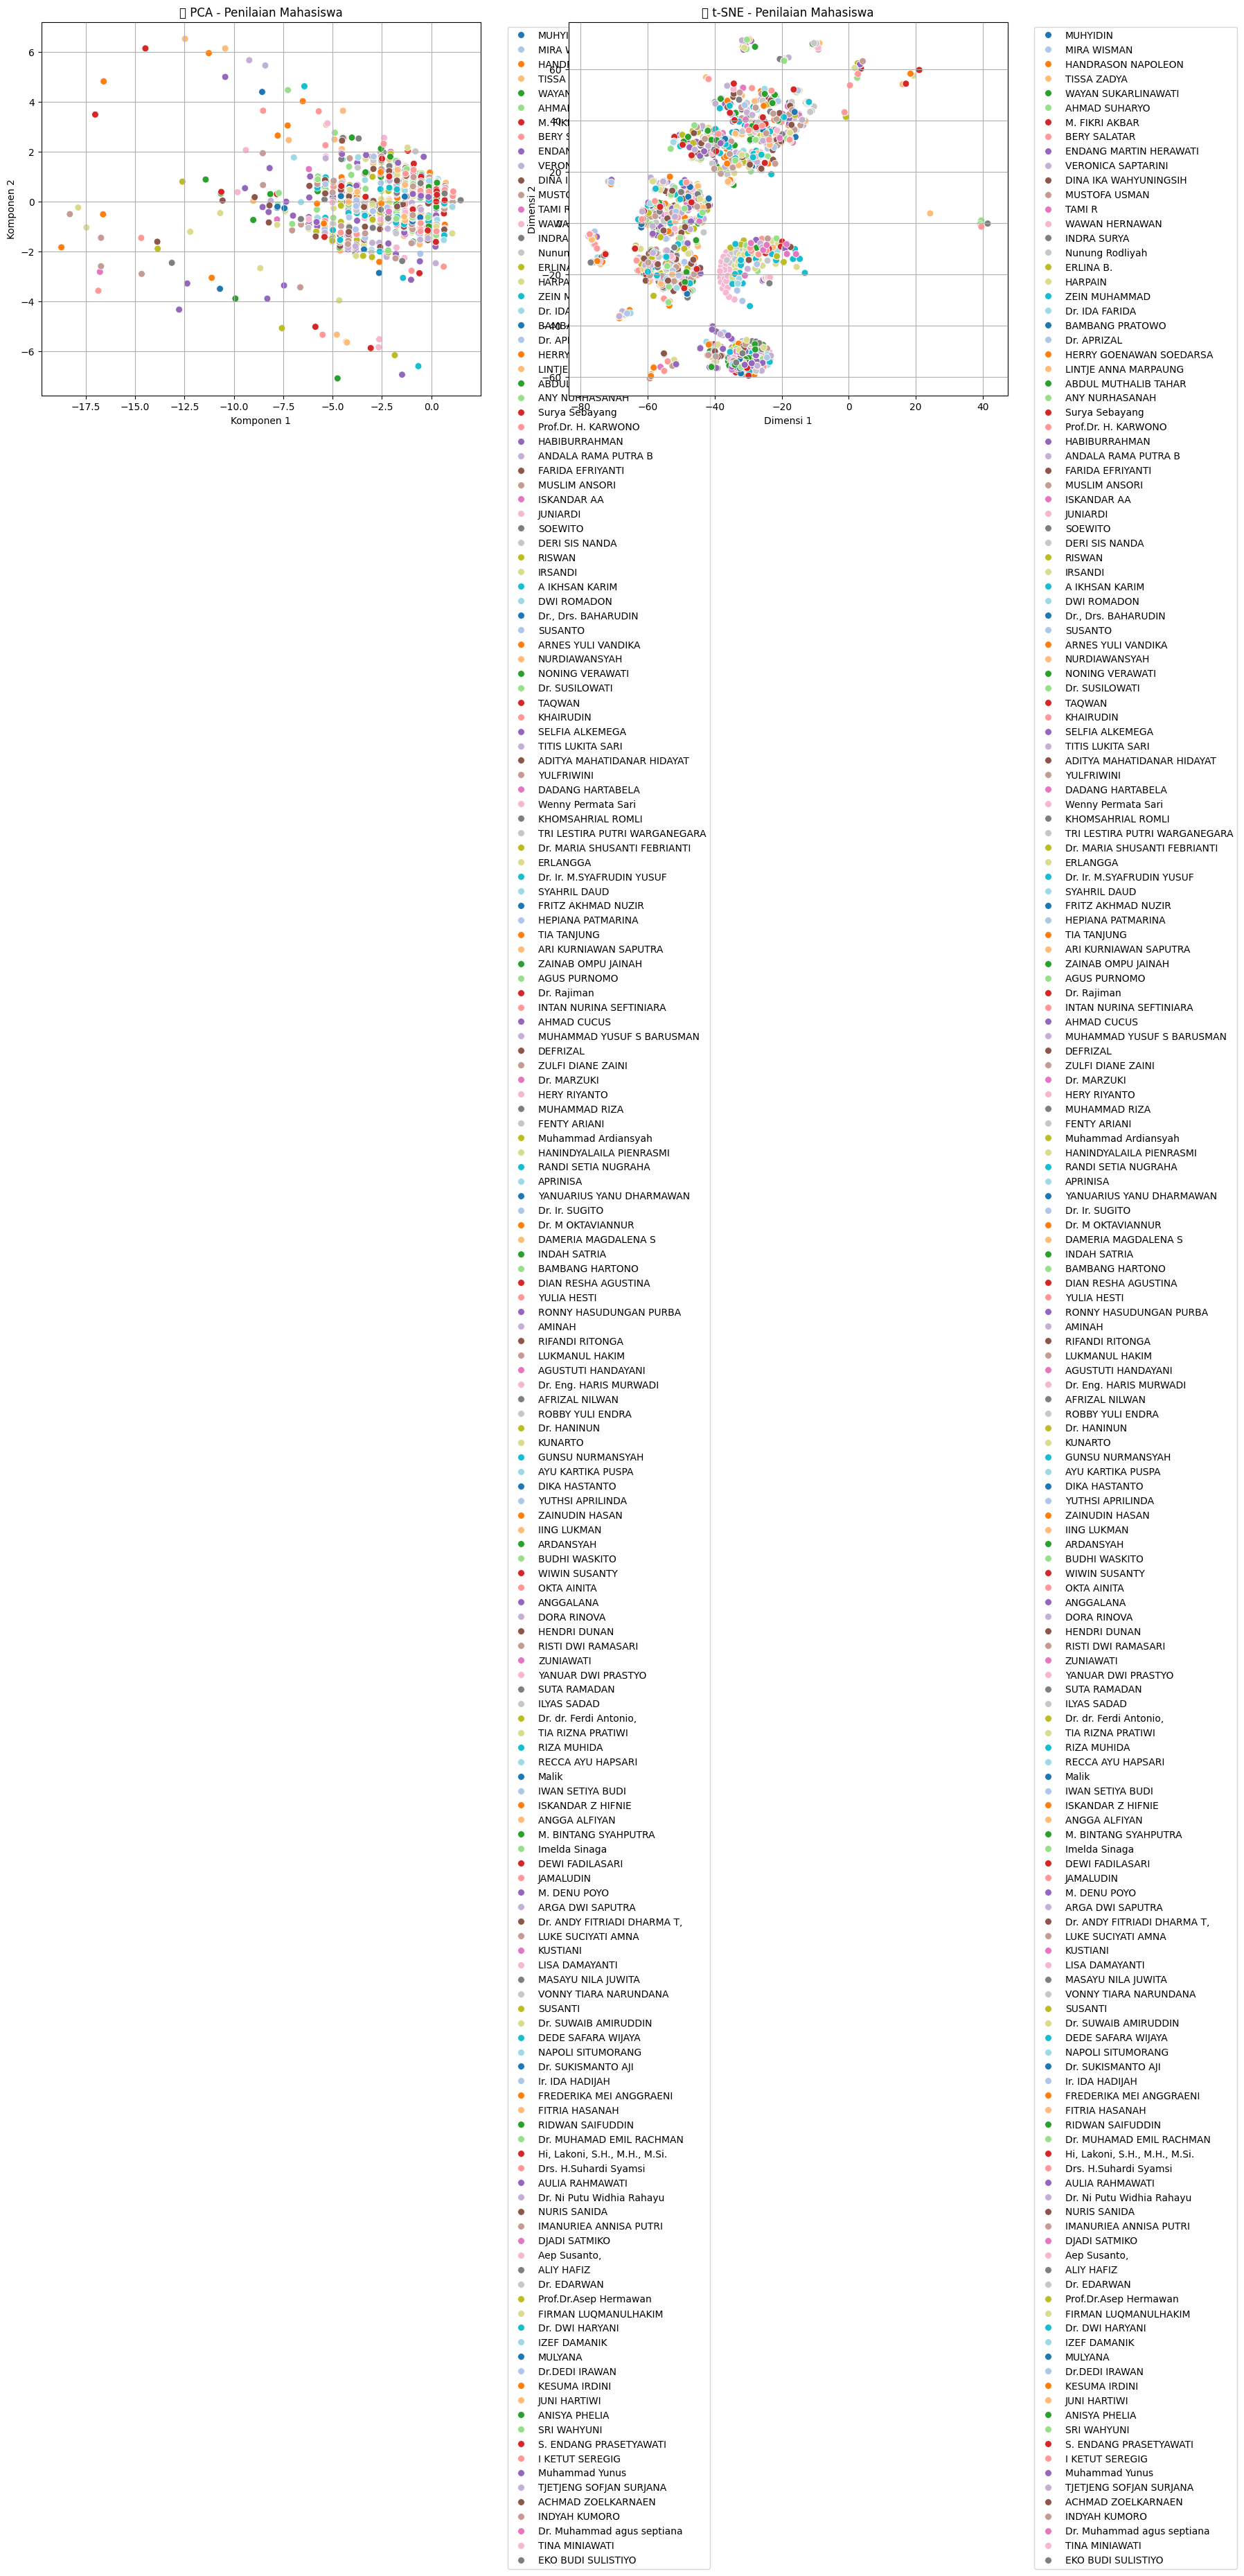

In [10]:
plt.figure(figsize=(18, 7))

# --- Grafik PCA ---
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50)
plt.title('📊 PCA - Penilaian Mahasiswa')
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# --- Grafik t-SNE ---
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50)
plt.title('🌀 t-SNE - Penilaian Mahasiswa')
plt.xlabel('Dimensi 1')
plt.ylabel('Dimensi 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_863/371633568.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_863/371633568.py:28: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_863/371633568.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


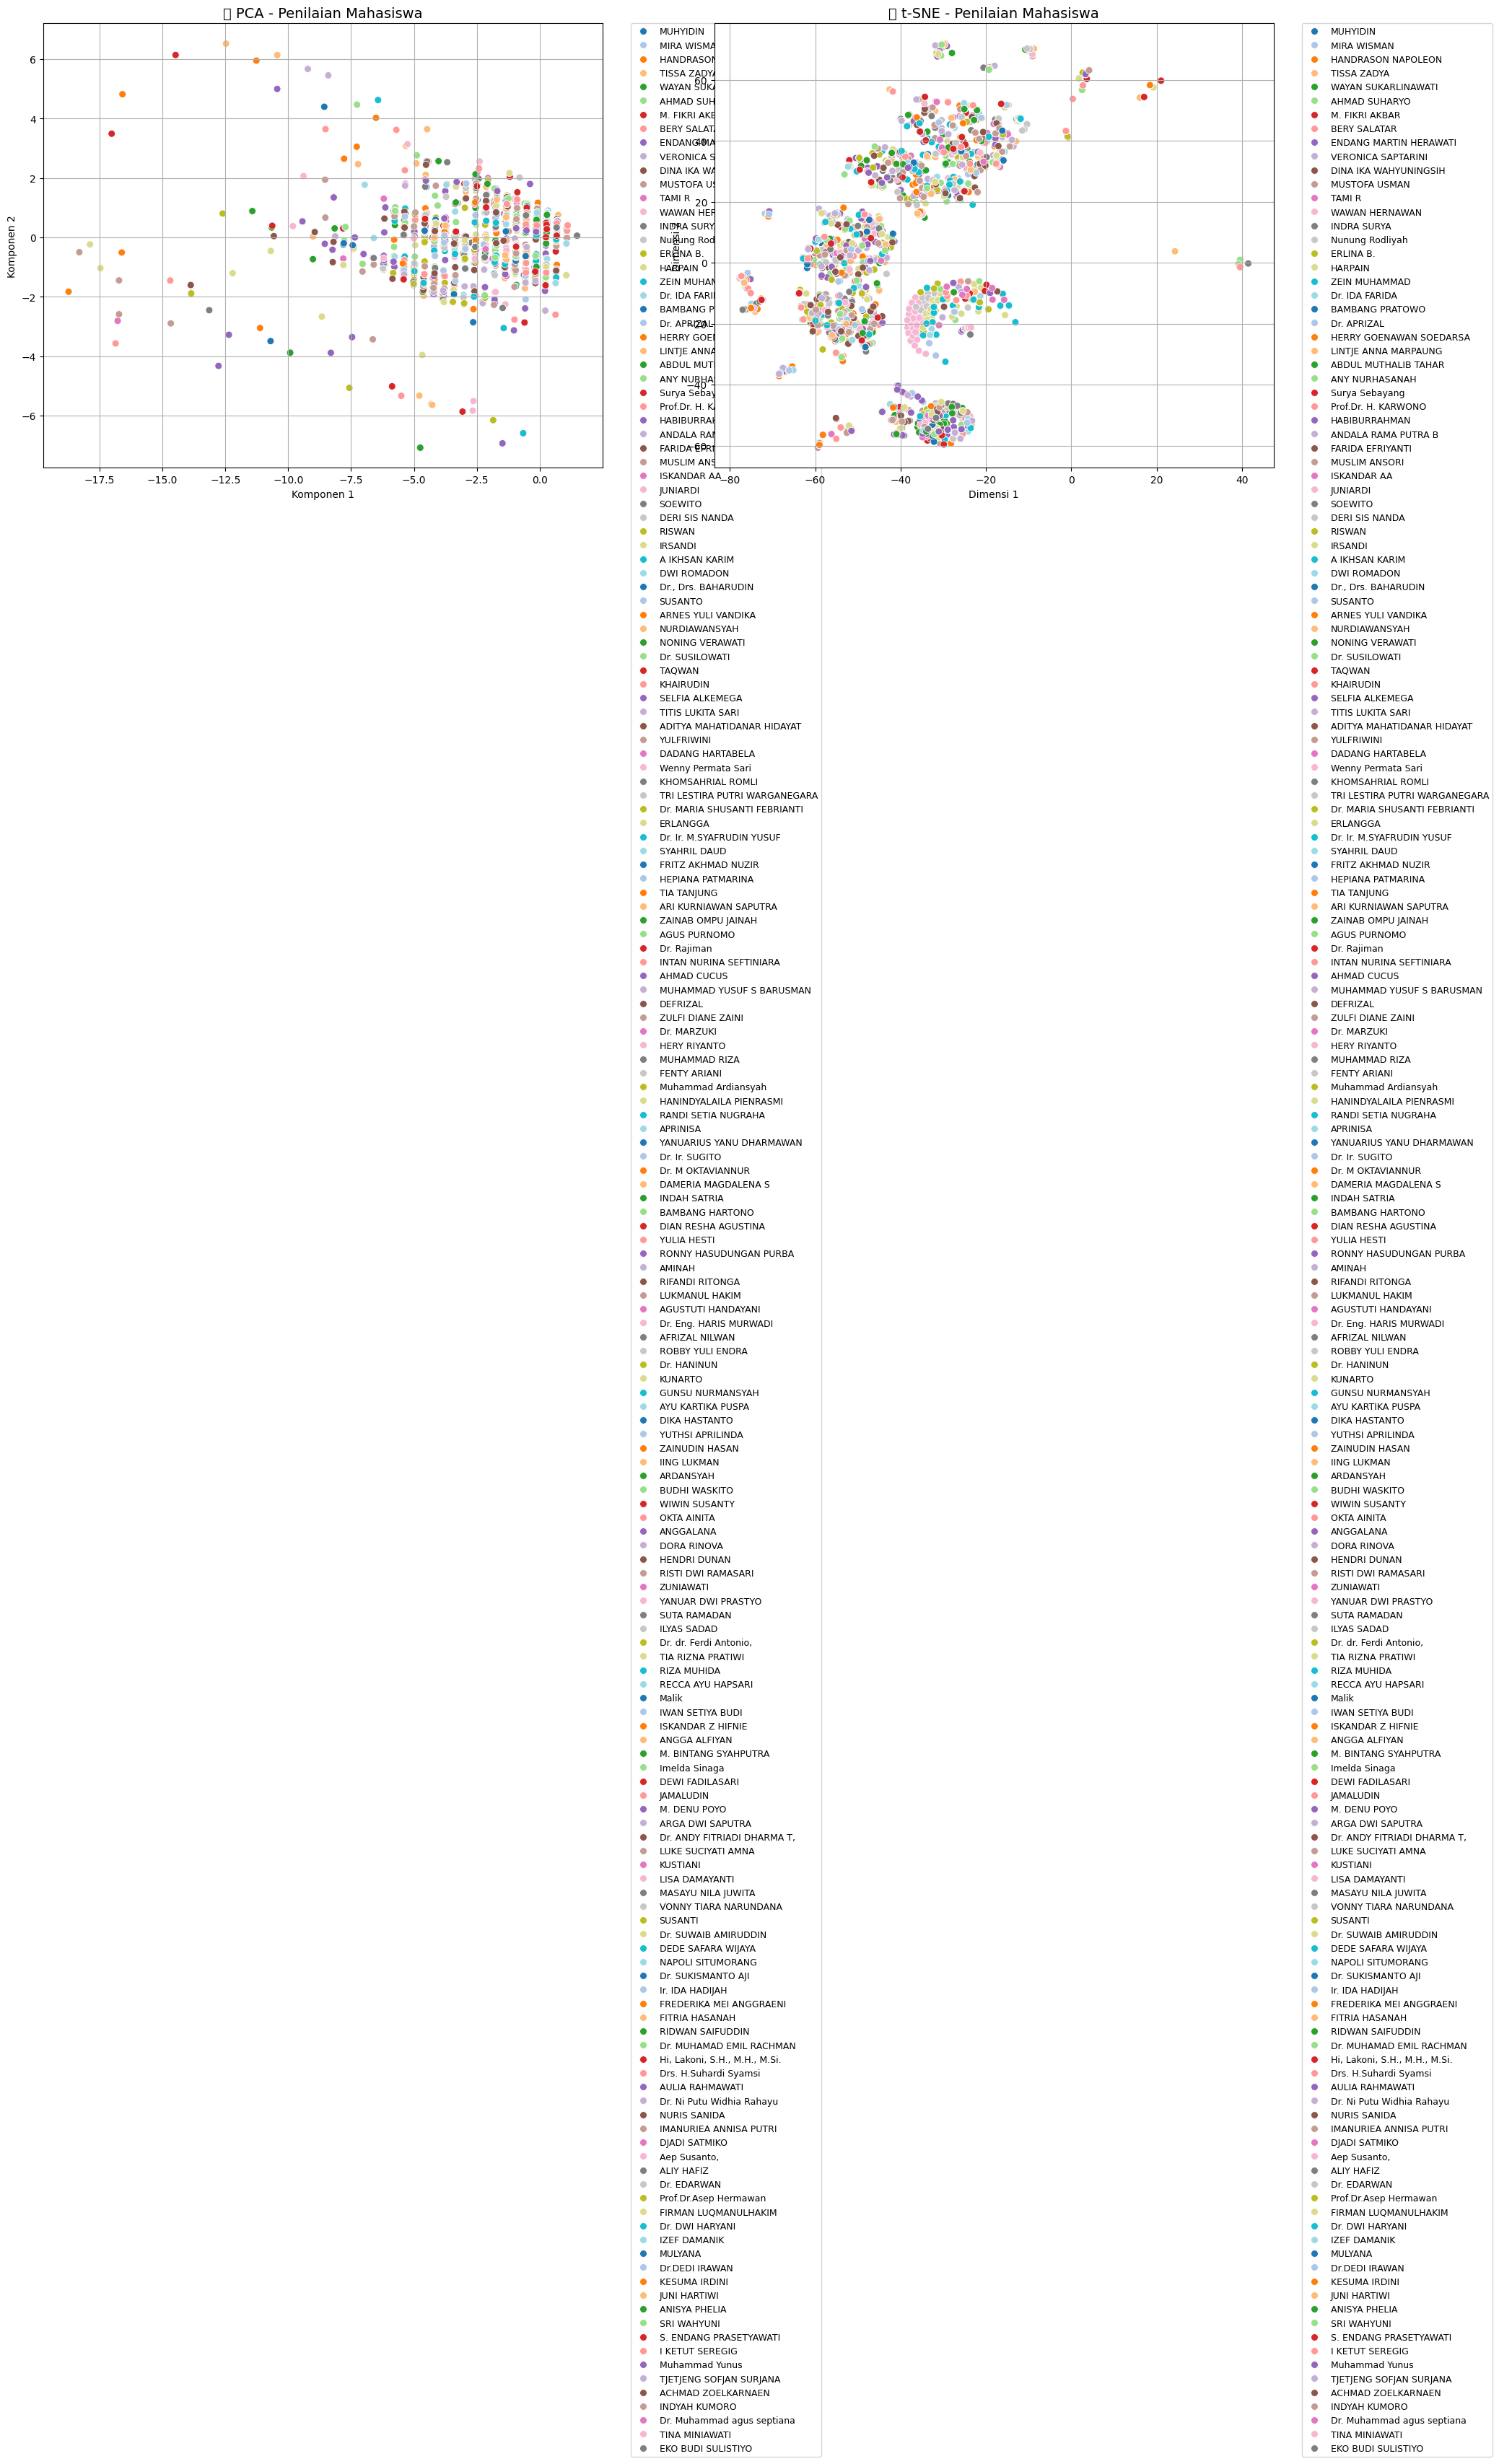

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 8))  #  Lebarkan ukuran agar legend tidak menumpuk

#  PCA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('📊 PCA - Penilaian Mahasiswa', fontsize=14)
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

# t-SNE
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('🌀 t-SNE - Penilaian Mahasiswa', fontsize=14)
plt.xlabel('Dimensi 1')
plt.ylabel('Dimensi 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

plt.tight_layout()
plt.show()


/tmp/ipykernel_863/1430248441.py:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])  # beri ruang untuk legend bawah
/tmp/ipykernel_863/1430248441.py:34: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.05, 1, 1])  # beri ruang untuk legend bawah
/tmp/ipykernel_863/1430248441.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.05, 1, 1])  # beri ruang untuk legend bawah
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


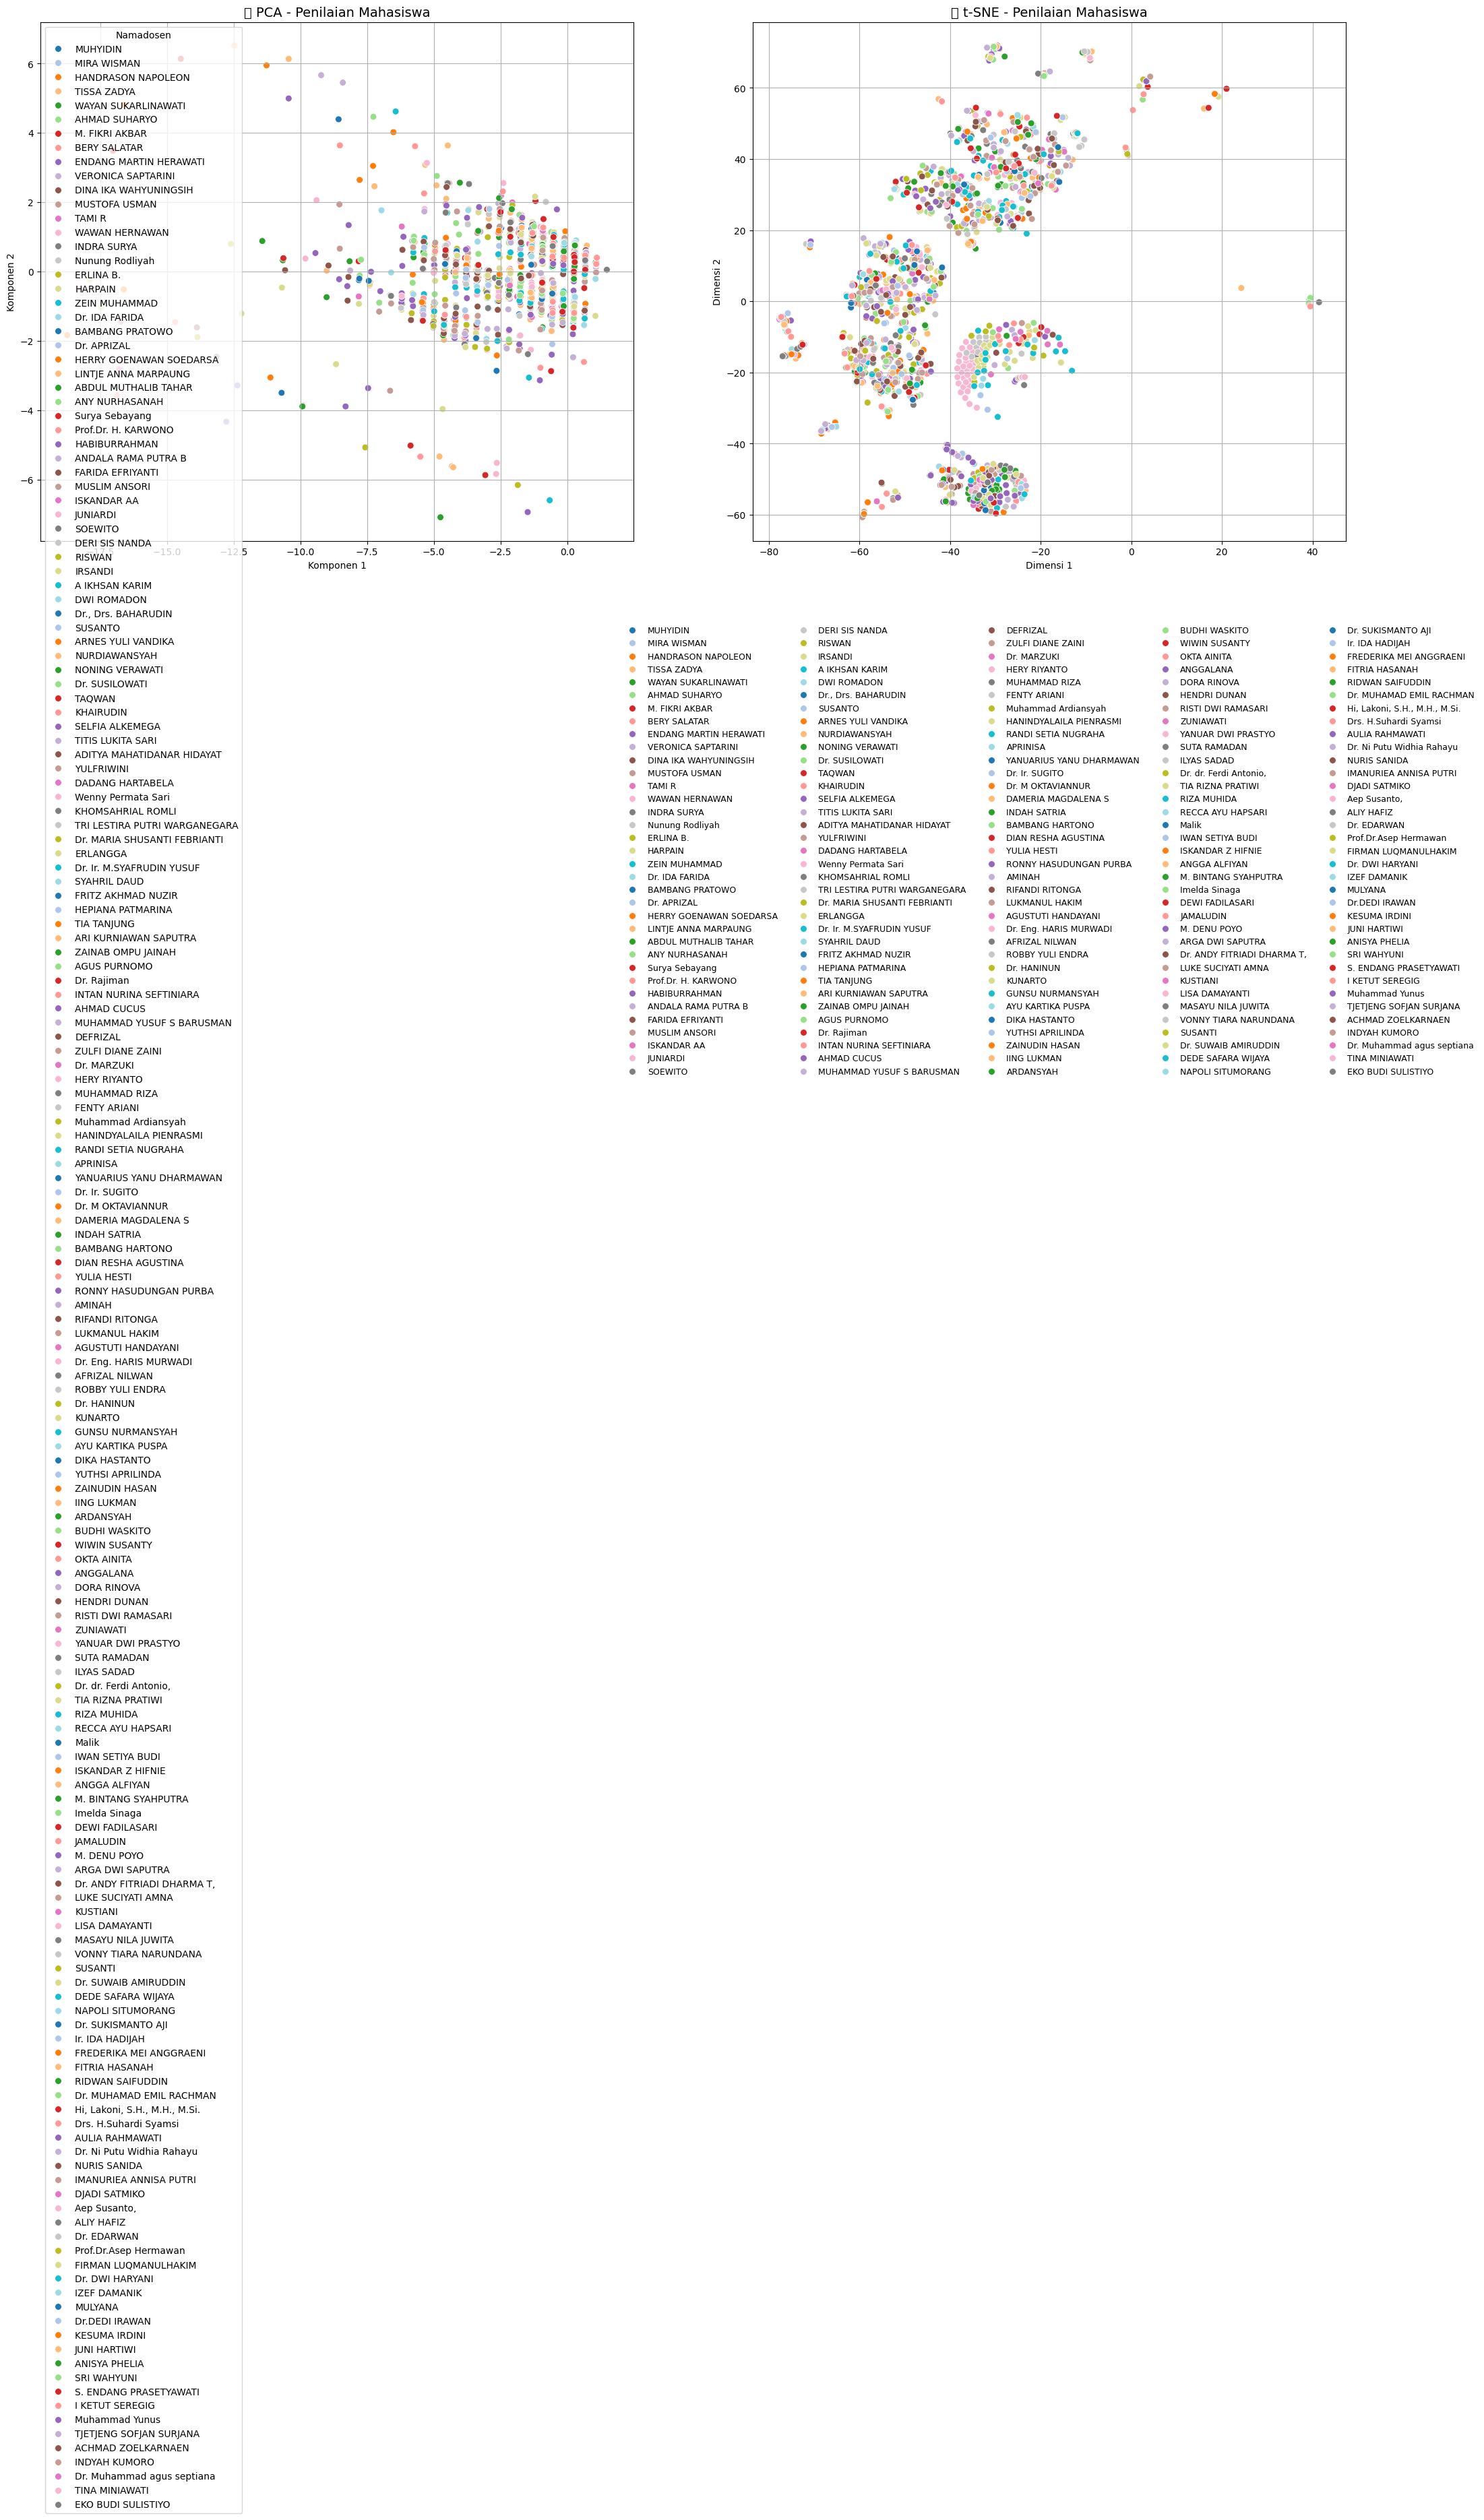

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perbesar area figure agar muat semua legend
plt.figure(figsize=(25, 10))

# --- PCA ---
ax1 = plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full', ax=ax1)
ax1.set_title('📊 PCA - Penilaian Mahasiswa', fontsize=14)
ax1.set_xlabel('Komponen 1')
ax1.set_ylabel('Komponen 2')
ax1.grid(True)

# --- t-SNE ---
ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50, legend='full', ax=ax2)
ax2.set_title('🌀 t-SNE - Penilaian Mahasiswa', fontsize=14)
ax2.set_xlabel('Dimensi 1')
ax2.set_ylabel('Dimensi 2')
ax2.grid(True)

# --- Atur legend agar tidak menumpuk ---
handles, labels = ax2.get_legend_handles_labels()
plt.legend(
    handles, labels,
    bbox_to_anchor=(0.5, -0.15),    # posisi legend DI BAWAH plot
    loc='upper center',
    ncol=5,                         #  jumlah kolom legend (bisa di ubah 4, 6, dst)
    fontsize=9,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # beri ruang untuk legend bawah
plt.show()


In [13]:
import plotly.express as px

fig = px.scatter(df, x='PC1', y='PC2', color='Namadosen', title='📊 PCA')
fig.show()


In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ambil hanya p1 - p10
X = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']]

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tambahkan hasil ke dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]


In [15]:
import pandas as pd
import numpy as np

# Membuat dataframe kontribusi PCA
loadings = pd.DataFrame(
    pca.components_.T,              # transpose biar kolom = PC1, PC2
    columns=['PC1', 'PC2'],
    index=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']
)

# Tambahkan kolom 'Dominan di' untuk melihat kontribusi terbesar
loadings['Dominan_di'] = np.where(abs(loadings['PC1']) > abs(loadings['PC2']), 'PC1', 'PC2')

print(loadings)


          PC1       PC2 Dominan_di
p1   0.282929  0.878310        PC2
p2   0.319049  0.199449        PC1
p3   0.318971  0.060605        PC1
p4   0.322757 -0.060845        PC1
p5   0.322239 -0.108483        PC1
p6   0.319852 -0.134386        PC1
p7   0.317477 -0.159640        PC1
p8   0.326749 -0.170113        PC1
p9   0.321824 -0.121773        PC1
p10  0.308178 -0.286943        PC1


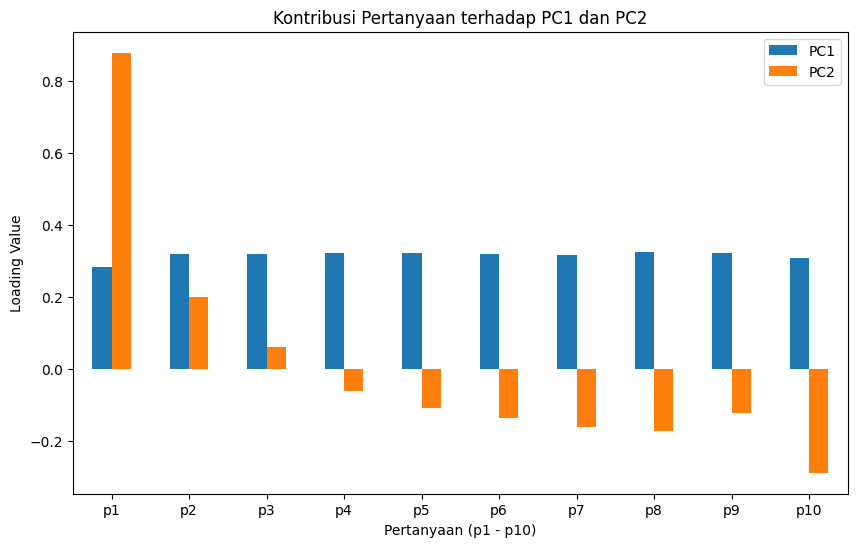

In [16]:
import matplotlib.pyplot as plt

loadings[['PC1','PC2']].plot(kind='bar', figsize=(10,6))
plt.title("Kontribusi Pertanyaan terhadap PC1 dan PC2")
plt.ylabel("Loading Value")
plt.xlabel("Pertanyaan (p1 - p10)")
plt.xticks(rotation=0)
plt.show()


/usr/local/lib/python3.13/dist-packages/IPython/core/events.py:89: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



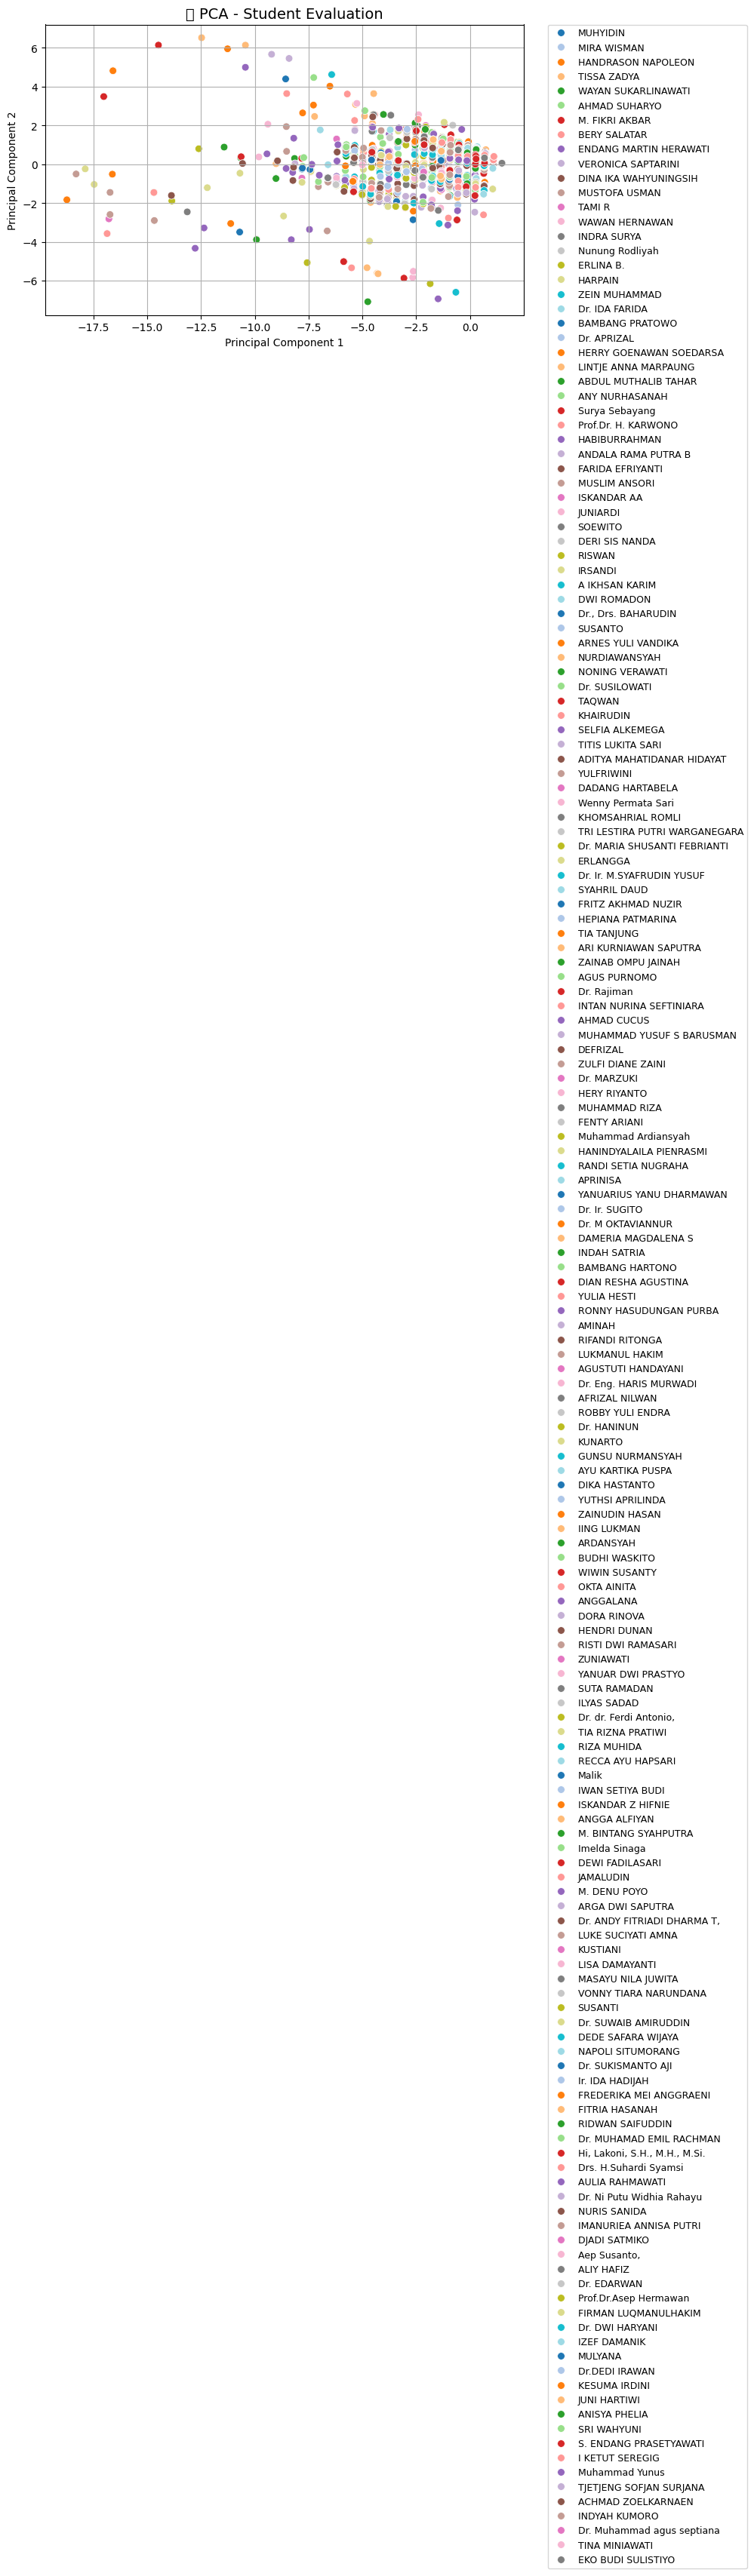

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))  #  Lebarkan ukuran agar legend tidak menumpuk

#  PCA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('📊 PCA - Student Evaluation', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

/tmp/ipykernel_863/1260146656.py:11: UserWarning:

Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_863/1260146656.py:11: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.



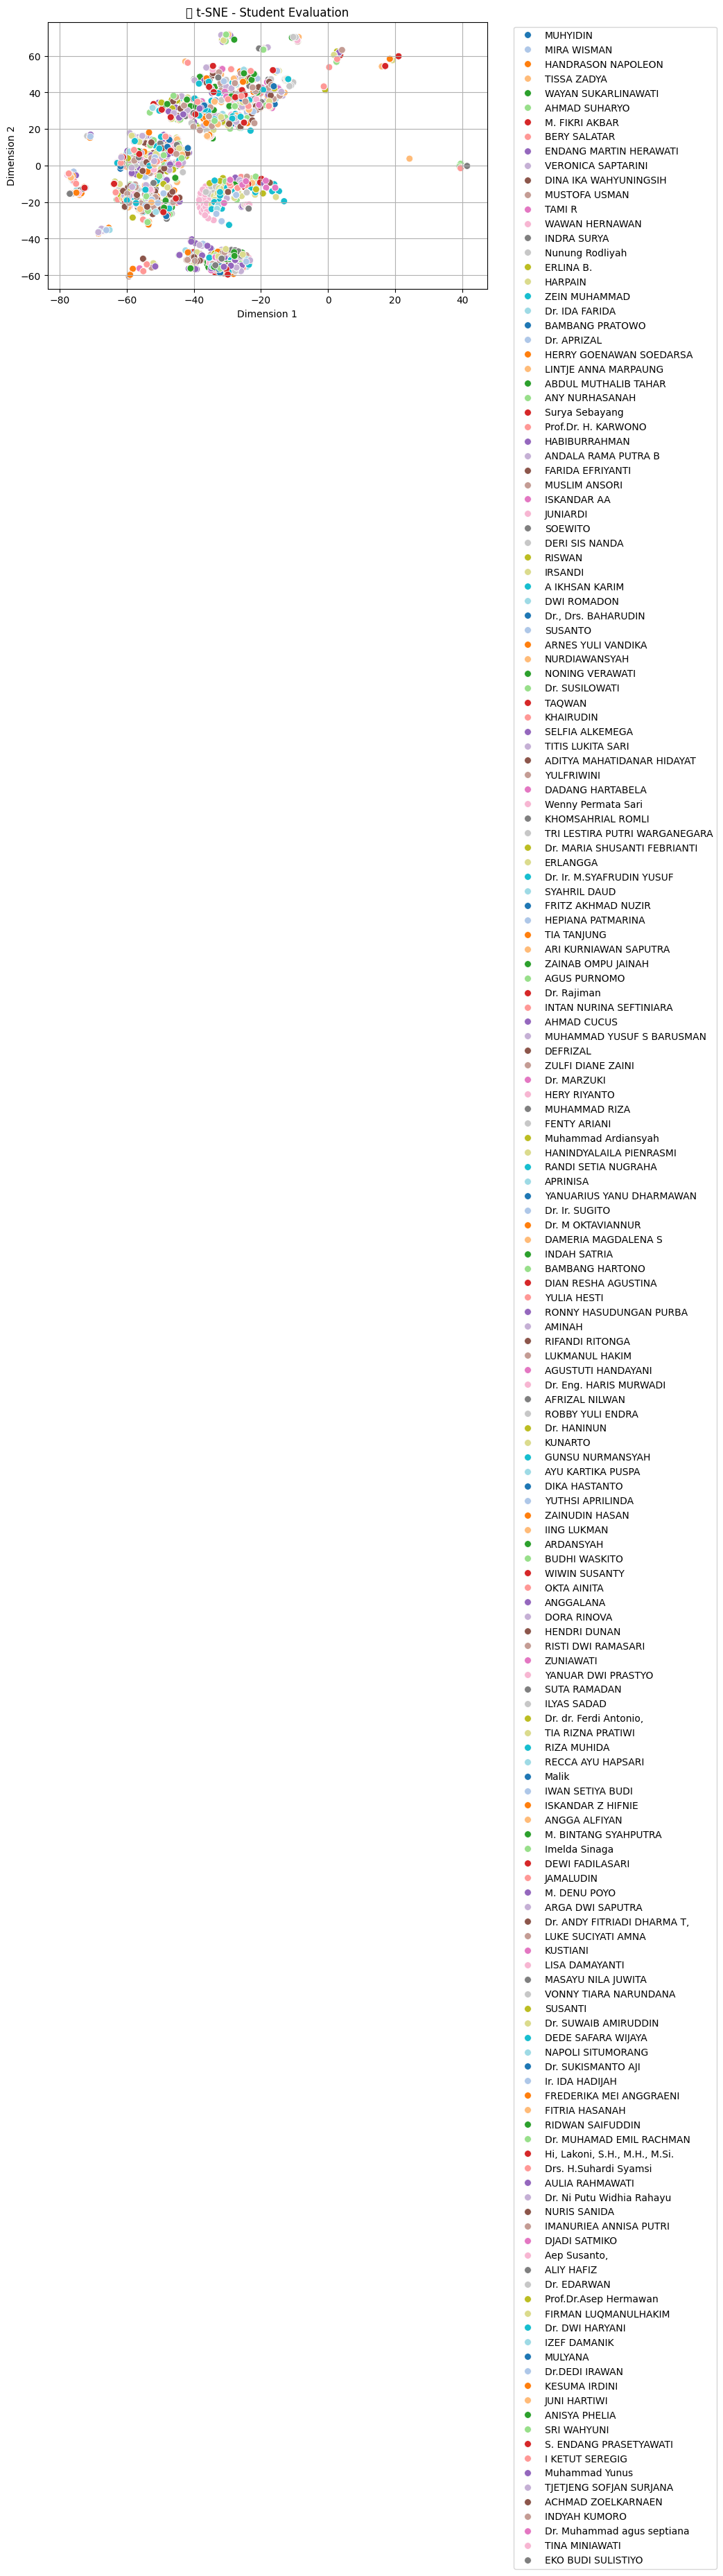

In [18]:
# --- Grafik t-SNE ---
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50)
plt.title('🌀 t-SNE - Student Evaluation')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_863/3735082275.py:33: UserWarning:

Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.

/tmp/ipykernel_863/3735082275.py:33: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.



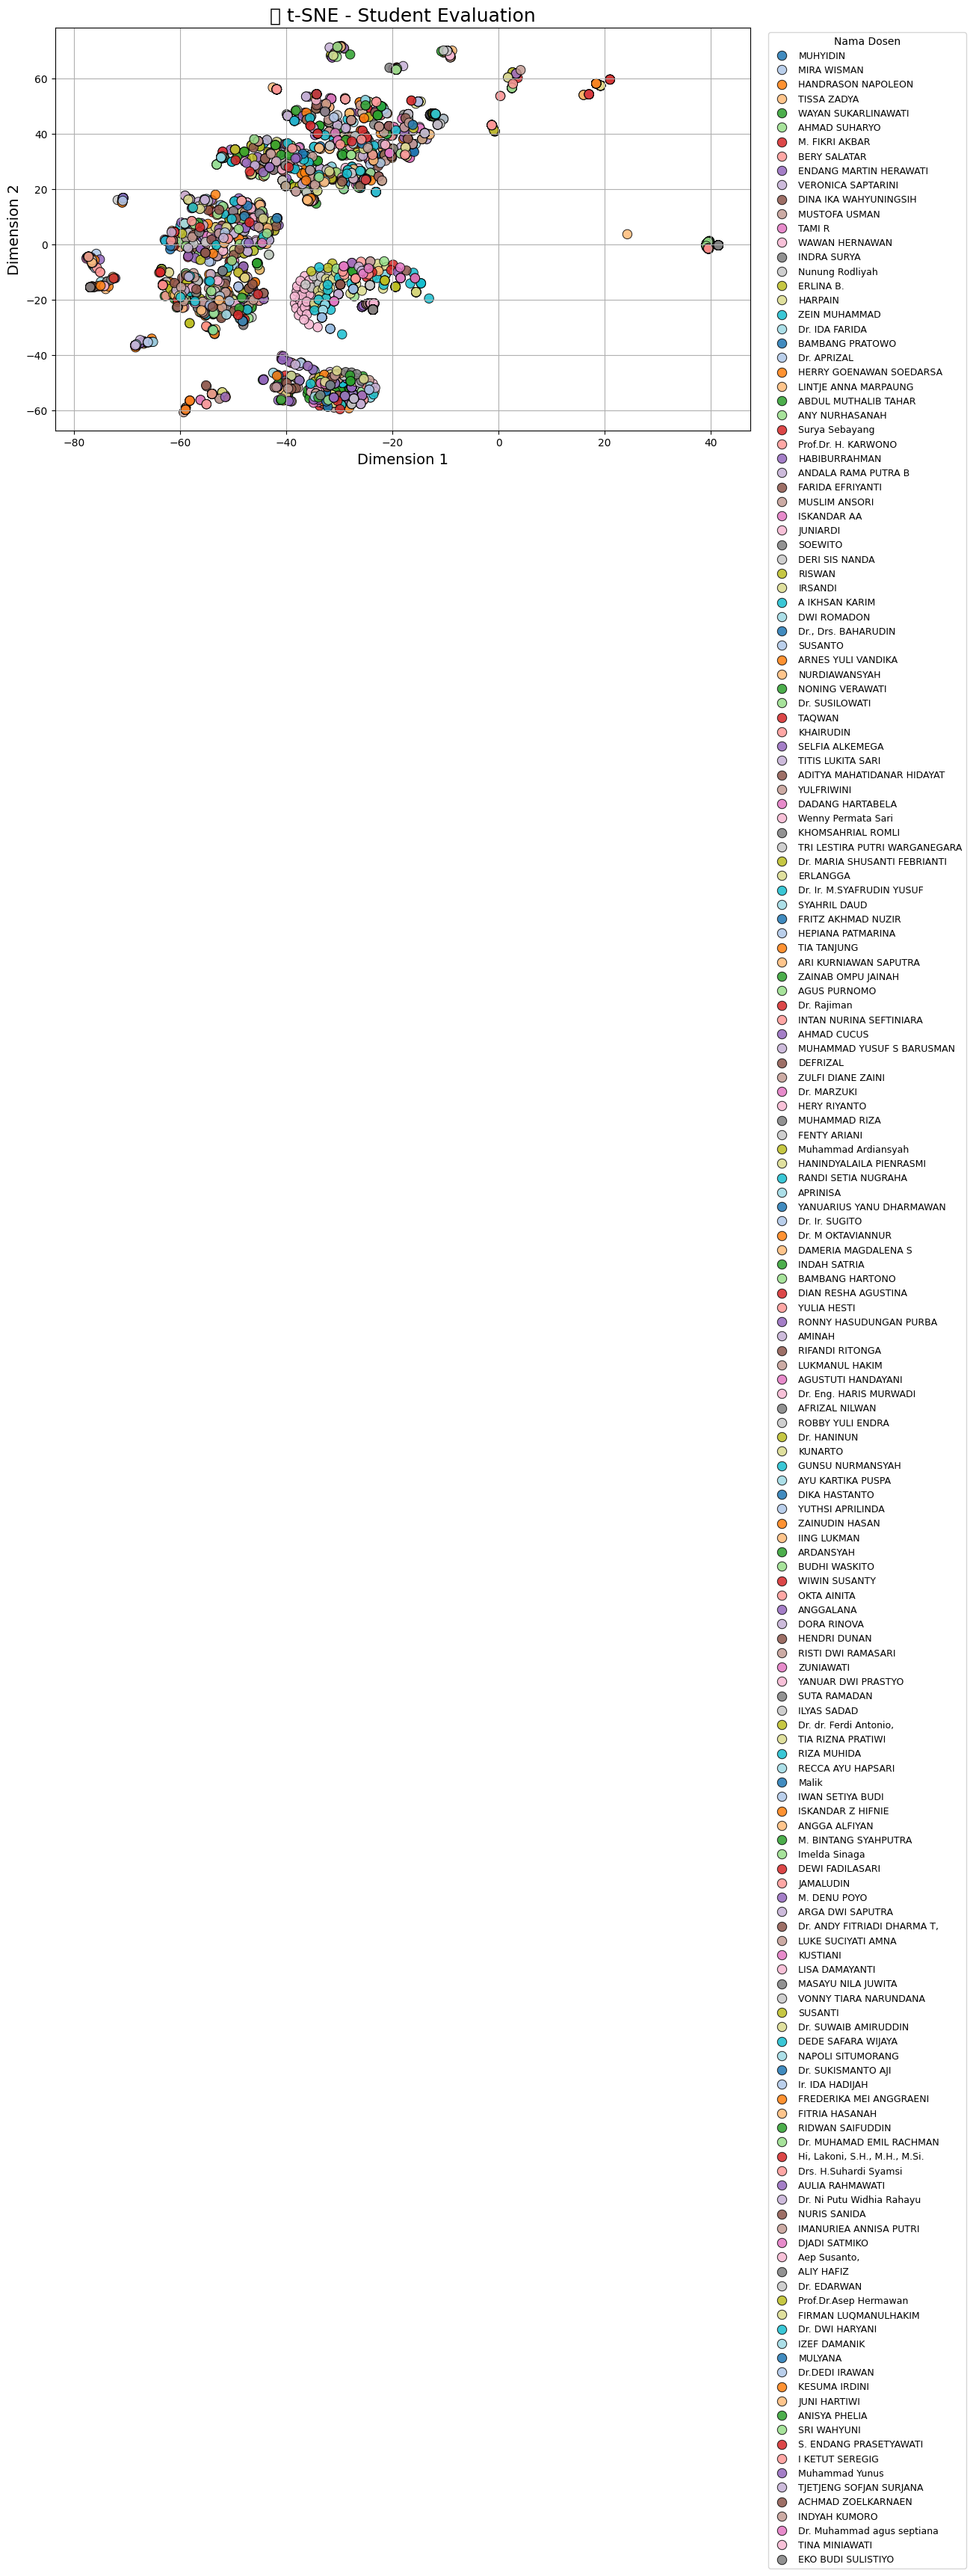

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perbesar ukuran figure
plt.figure(figsize=(12, 7))

# Scatter plot t-SNE
sns.scatterplot(
    data=df,
    x='TSNE1',
    y='TSNE2',
    hue='Namadosen',
    palette='tab20',
    s=80,              # Perbesar titik
    edgecolor='black', # Tambah outline biar jelas
    alpha=0.85
)

plt.title('🌀 t-SNE - Student Evaluation', fontsize=18)
plt.xlabel('Dimension 1', fontsize=14)
plt.ylabel('Dimension 2', fontsize=14)

plt.grid(True)

# Legend di luar dan dibuat lebih rapi
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    title='Nama Dosen'
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_863/480443864.py:36: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



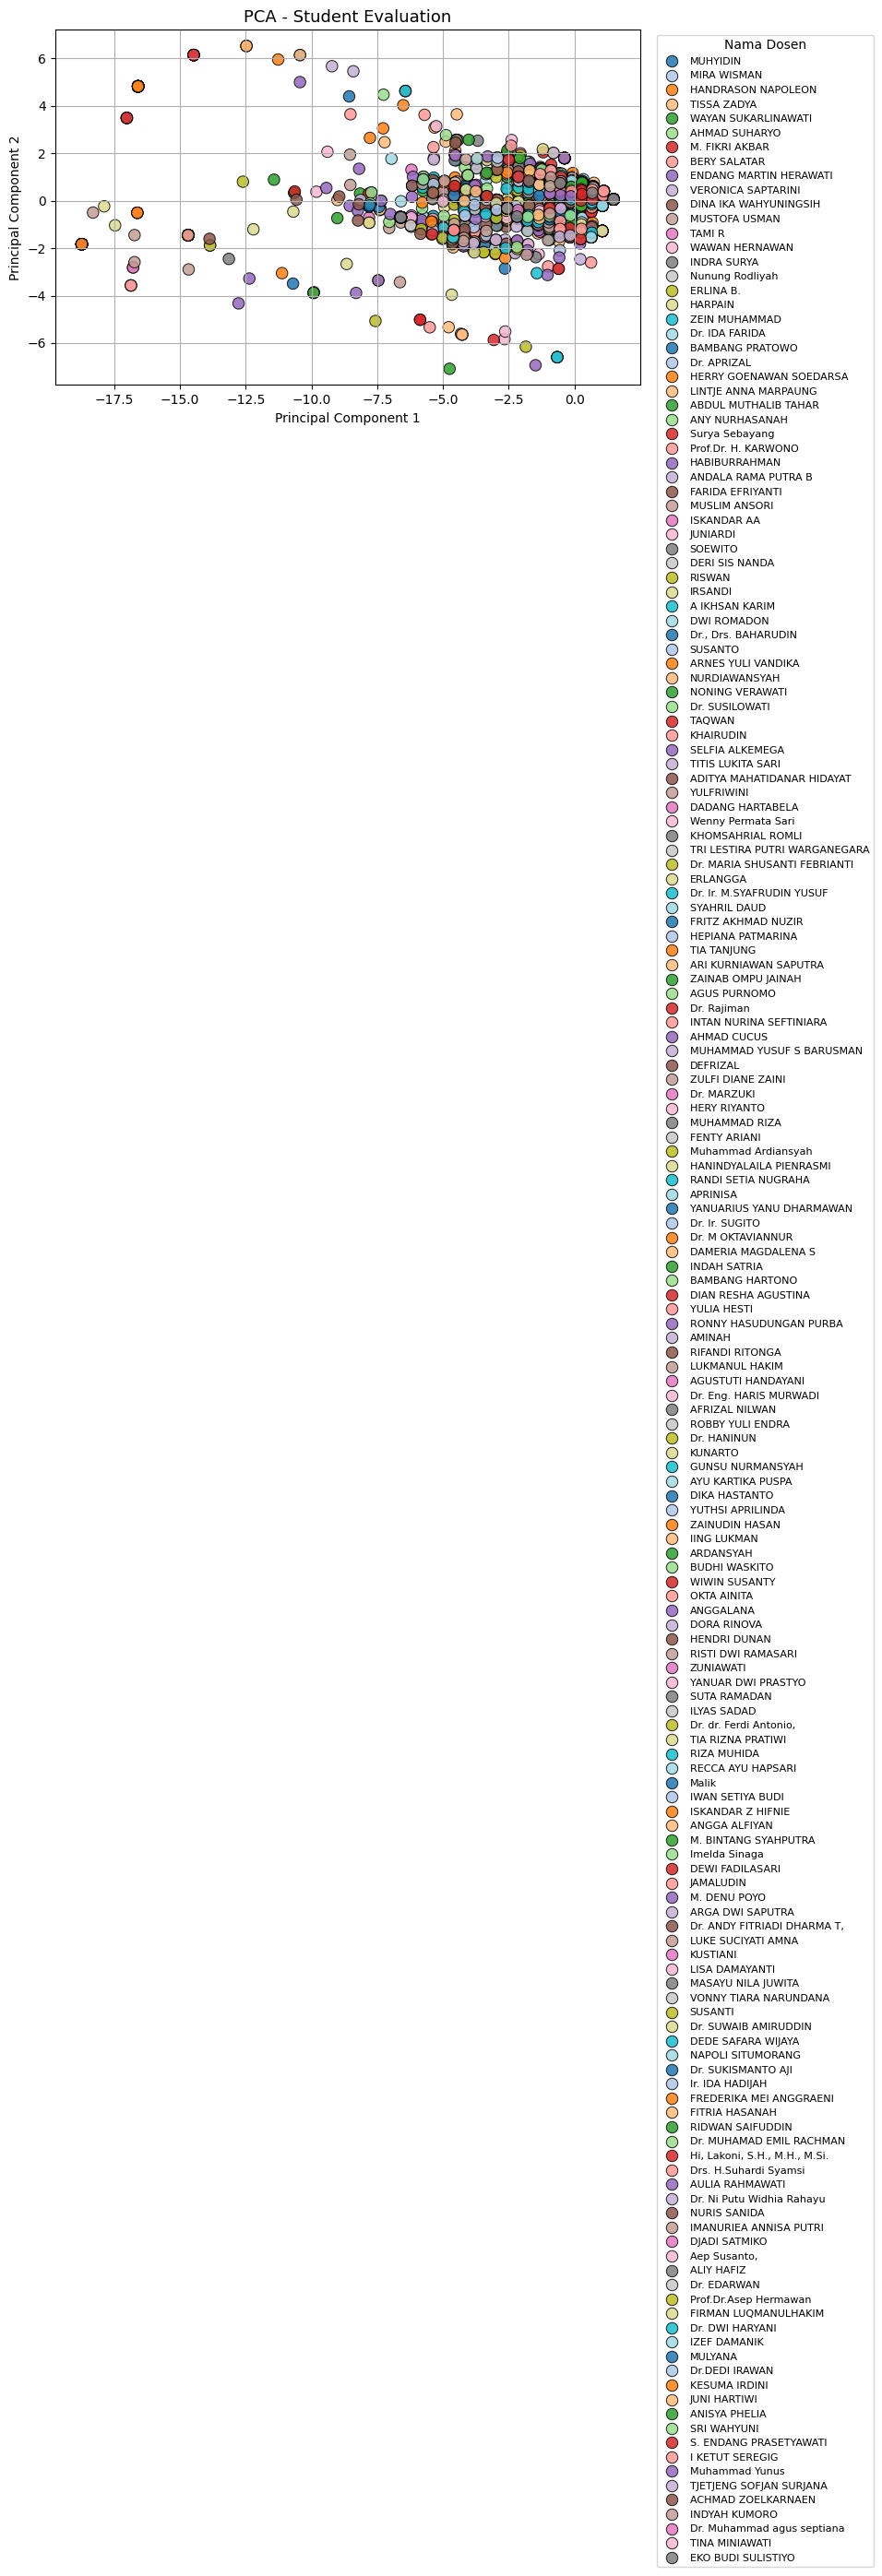

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))  # Perbesar ukuran keseluruhan

# ======================
# PCA
# ======================
plt.subplot(1, 2, 1)

sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Namadosen',
    palette='tab20',
    s=80,              # Perbesar titik
    edgecolor='black', # Tambah outline agar jelas
    alpha=0.85
)

plt.title('PCA - Student Evaluation', fontsize=13)
plt.xlabel('Principal Component 1', fontsize=10)
plt.ylabel('Principal Component 2', fontsize=10)

plt.grid(True)

# Legend keluar supaya lebih rapi
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    title='Nama Dosen'
)

plt.tight_layout()
plt.show()


In [21]:
print(X_pca)

[[ 1.48365003  0.05449667]
 [ 1.48365003  0.05449667]
 [-0.50547263  0.86154336]
 ...
 [ 1.48365003  0.05449667]
 [-2.55964772 -0.3226184 ]
 [ 1.48365003  0.05449667]]
